In [13]:
import pandas as pd
import numpy as np
import joblib

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

In [14]:
df = pd.read_csv(
    "../data/processed/feature_engineered_ai4i2020.csv"
)

df.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,Temperature_Difference,Mechanical_Stress,Type_Encoded,Type_H,Type_L,Type_M,Wear_Stress_Index
0,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0,10.5,66382.8,2,False,False,True,0.0
1,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0,10.5,65190.4,1,False,True,False,138.9
2,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0,10.4,74001.2,1,False,True,False,247.0
3,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0,10.4,56603.5,1,False,True,False,276.5
4,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0,10.5,56320.0,1,False,True,False,360.0


In [15]:
features = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
    "Temperature_Difference",
    "Mechanical_Stress",
    "Wear_Stress_Index",
    "Type_L",
    "Type_M"
]

X = df[features]

y = df["Machine failure"]

In [16]:
model = joblib.load(
    "../models/predictive_maintenance_model.pkl"
)

In [17]:
predictions = model.predict(X)

probabilities = model.predict_proba(X)[:,1]

In [18]:
print(
    classification_report(
        y,
        predictions
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9661
           1       0.98      0.95      0.97       339

    accuracy                           1.00     10000
   macro avg       0.99      0.98      0.98     10000
weighted avg       1.00      1.00      1.00     10000



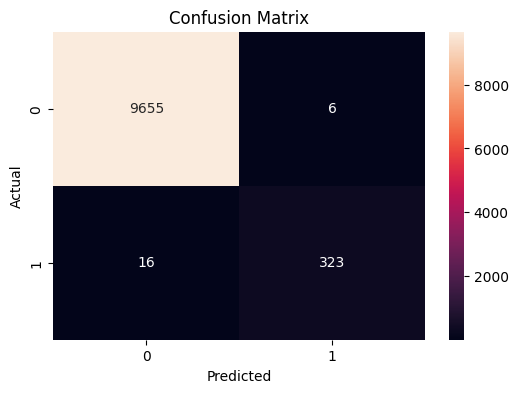

In [19]:
cm = confusion_matrix(y, predictions)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [20]:
roc_score = roc_auc_score(
    y,
    probabilities
)

print(
    f"ROC-AUC Score: {roc_score:.4f}"
)

ROC-AUC Score: 0.9975


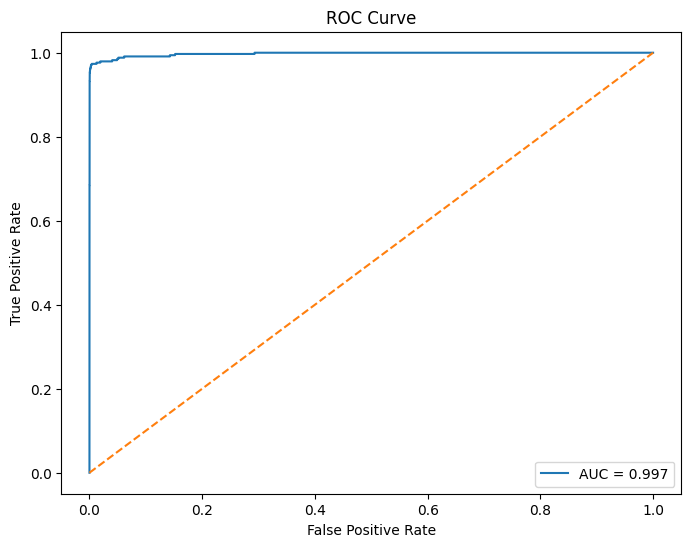

In [21]:
fpr, tpr, thresholds = roc_curve(
    y,
    probabilities
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_score:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

In [22]:
importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df

,Feature,Importance
2,Rotational speed [rpm],0.223393
3,Torque [Nm],0.180721
6,Mechanical_Stress,0.176057
4,Tool wear [min],0.132888
7,Wear_Stress_Index,0.125163
5,Temperature_Difference,0.083902
0,Air temperature [K],0.044127
1,Process temperature [K],0.026193
9,Type_M,0.003931
8,Type_L,0.003624


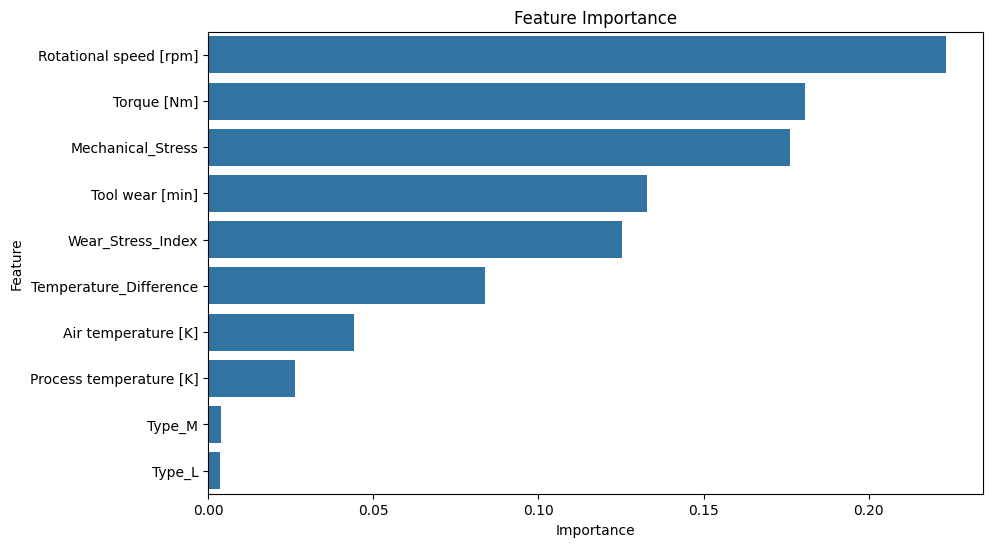

In [23]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance_df,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")

plt.show()

In [24]:
def classify_risk(prob):

    if prob < 0.25:
        return "Low"

    elif prob < 0.50:
        return "Medium"

    elif prob < 0.75:
        return "High"

    else:
        return "Critical"

In [26]:
df["Failure_Probability"] = probabilities

df["Risk_Category"] = (
    df["Failure_Probability"]
    .apply(classify_risk)
)

df[
    [
        "Failure_Probability",
        "Risk_Category"
    ]
].head()

,Failure_Probability,Risk_Category
0,0.004656,Low
1,0.016765,Low
2,0.004103,Low
3,0.007616,Low
4,0.007616,Low


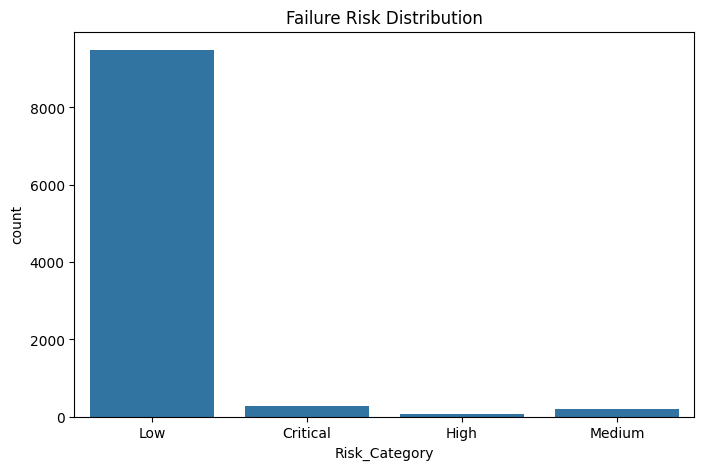

In [27]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Risk_Category"
)

plt.title("Failure Risk Distribution")

plt.show()

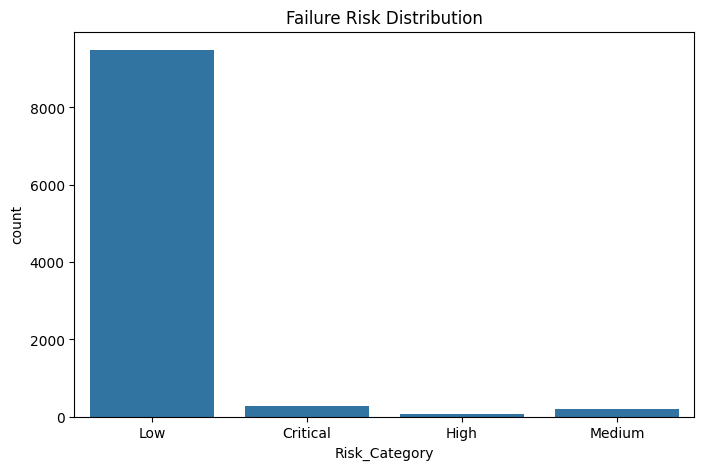

In [28]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Risk_Category"
)

plt.title("Failure Risk Distribution")

plt.show()

In [29]:
risk_summary = (
    df["Risk_Category"]
    .value_counts()
)

print(risk_summary)

Risk_Category
Low         9487
Critical     267
Medium       184
High          62
Name: count, dtype: int64


In [30]:
high_risk = df[
    df["Risk_Category"].isin(
        ["High","Critical"]
    )
]

high_risk.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,...,RNF,Temperature_Difference,Mechanical_Stress,Type_Encoded,Type_H,Type_L,Type_M,Wear_Stress_Index,Failure_Probability,Risk_Category
50,L,298.9,309.1,2861,4.6,143,1,0,0,1,...,0,10.2,13160.6,1,False,True,False,657.8,0.995000,Critical
69,L,298.9,309.0,1410,65.7,191,1,0,0,1,...,0,10.1,92637.0,1,False,True,False,12548.7,0.949621,Critical
77,L,298.8,308.9,1455,41.3,208,1,1,0,0,...,0,10.1,60091.5,1,False,True,False,8590.4,0.597204,High
160,L,298.4,308.2,1282,60.7,216,1,0,0,0,...,0,9.8,77817.4,1,False,True,False,13111.2,0.964442,Critical
161,L,298.3,308.1,1412,52.3,218,1,0,0,0,...,0,9.8,73847.6,1,False,True,False,11401.4,0.896877,Critical


In [31]:
reporting_df = df.copy()

reporting_df.to_csv(
    "../data/processed/predictive_maintenance_reporting.csv",
    index=False
)

print("Reporting Dataset Saved")

Reporting Dataset Saved
